#spam image classification

In [1]:
#necessary imports
import numpy as np
import pandas as pd

In [2]:
import pandas as pd

# Read the CSV file with 'latin1' encoding
df = pd.read_csv('/kaggle/input/sms-spam-collection-dataset/spam.csv', encoding='latin1')


In [3]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3619,ham,I meant as an apology from me for texting you ...,NaN,NaN,NaN
2573,spam,Congrats 2 mobile 3G Videophones R yours. call...,NaN,NaN,NaN
992,ham,Up to Ì_... ÌÏ wan come then come lor... But i...,NaN,NaN,NaN
2658,ham,Not yet chikku..wat abt u?,NaN,NaN,NaN
5219,ham,Pls she needs to dat slowly or she will vomit ...,NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

**Data Cleaning**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


most of the values in 2, 3, 4 column are missing

In [6]:
#droping last three columns
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)


In [7]:
df.sample(5)

,v1,v2
1167,ham,Lol now I'm after that hot air balloon!
1716,ham,Sorry about earlier. Putting out fires.Are you...
3577,ham,They said Ì_ dun haf passport or smth like dat...
5566,spam,REMINDER FROM O2: To get 2.50 pounds free call...
1993,ham,Eh den sat u book e kb liao huh...


In [8]:
#renaming the columns
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
4759,ham,I'm home. Doc gave me pain meds says everythin...
2875,ham,Fuck cedar key and fuck her (come over anyway ...
3740,spam,2/2 146tf150p
3985,ham,"Friendship is not a game to play, It is not a ..."
3126,ham,Thats cool. i liked your photos. You are very ...


In [9]:
# Importing LabelEncoder class from the sklearn.preprocessing module
from sklearn.preprocessing import LabelEncoder

# Creating an instance of the LabelEncoder class
encoder = LabelEncoder()


In [10]:
# Using the LabelEncoder instance 'encoder' to transform the 'target' column of DataFrame 'df'
# fit_transform() method fits label encoder and transforms the target column into encoded numerical values
df['target'] = encoder.fit_transform(df['target'])


In [11]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
#checking missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [13]:
#checking duplicate values
df.duplicated().sum()

403

In [14]:
#remove duplicated
df=df.drop_duplicates(keep='first')

In [15]:
df.duplicated().sum()

0

In [16]:
df.shape

(5169, 2)

**EDA**

In [17]:
# Counting the occurrences of each unique value in the 'target' column
# Useful for understanding the distribution of classes in the target variable
df['target'].value_counts()


target
0    4516
1     653
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x7e4b096ceef0>,
 [Text(-1.0144997251399075, 0.42519443516002464, 'ham'),
  Text(1.014499764949479, -0.4251943401757036, 'spam')],
 [Text(-0.5533634864399495, 0.23192423736001339, '87.37'),
  Text(0.5533635081542612, -0.23192418555038377, '12.63')])

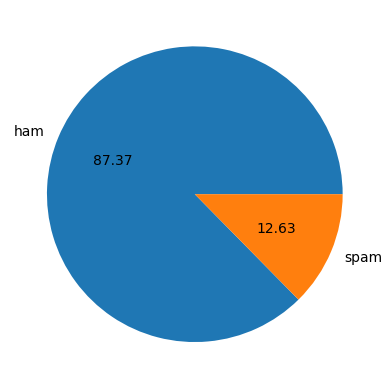

In [18]:
# Importing the matplotlib.pyplot module for data visualization
import matplotlib.pyplot as plt

# Creating a pie chart to visualize the distribution of classes in the 'target' column
# 'df['target'].value_counts()' counts the occurrences of each unique value in the 'target' column
# 'labels=['ham','spam']' provides labels for the pie chart slices
# 'autopct="%0.2f"' specifies the format of the percentage labels on the pie chart
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct="%0.2f")


this data is imbalance

In [19]:
# Importing the nltk library for natural language processing tasks
import nltk


In [20]:
# Downloading the 'punkt' tokenizer models from the NLTK data repository
nltk.download('punkt')


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [21]:
# Creating a new column 'num_characters' in the DataFrame 'df' 
# Applying the len() function to calculate the number of characters in each text entry of the 'text' column
df['num_characters'] = df['text'].apply(len)


this is calculating the number of charater used in each ham and spam

In [22]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [23]:
# Creating a new column 'num_words' in the DataFrame 'df'
# Using the nltk.word_tokenize() function to tokenize each text entry in the 'text' column and then calculating the number of tokens
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))


In [24]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,23
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [25]:
#counting number of sentence in in text column
df["num_sentence"]=df['text'].apply(lambda x:(len(nltk.sent_tokenize(x))))

In [26]:
df.head()

,target,text,num_characters,num_words,num_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,23,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [27]:
# Generating descriptive statistics for the columns 'num_characters', 'num_words', and 'num_sentence'
# This provides summary statistics such as count, mean, standard deviation, minimum, maximum, and quartile values for each of these columns
df[['num_characters', 'num_words', 'num_sentence']].describe()


,num_characters,num_words,num_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.286129,1.961308
std,58.236293,13.226400,1.432583
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,219.000000,38.000000


now we are describing for ham message and spam massege in different

In [28]:
# Generating descriptive statistics for the columns 'num_characters', 'num_words', and 'num_sentence'
# This is specifically for messages classified as 'ham' (non-spam) in the 'target' column
# The DataFrame is filtered to include only rows where 'target' is 0 (indicating 'ham' messages)
# Summary statistics are then computed for these columns
df[df['target'] == 0][['num_characters', 'num_words', 'num_sentence']].describe()


,num_characters,num_words,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,16.957484,1.815545
std,56.358207,13.394052,1.364098
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,219.000000,38.000000


In [29]:
# Generating descriptive statistics for the columns 'num_characters', 'num_words', and 'num_sentence'
# This is specifically for messages classified as 'spam' in the 'target' column
# The DataFrame is filtered to include only rows where 'target' is 1 (indicating 'spam' messages)
# Summary statistics are then computed for these columns
df[df['target'] == 1][['num_characters', 'num_words', 'num_sentence']].describe()


,num_characters,num_words,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.474732,2.969372
std,30.137753,6.893007,1.488910
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,44.000000,9.000000


lets see the correlation

In [33]:
df.head()

,target,text,num_characters,num_words,num_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,23,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


<Axes: >

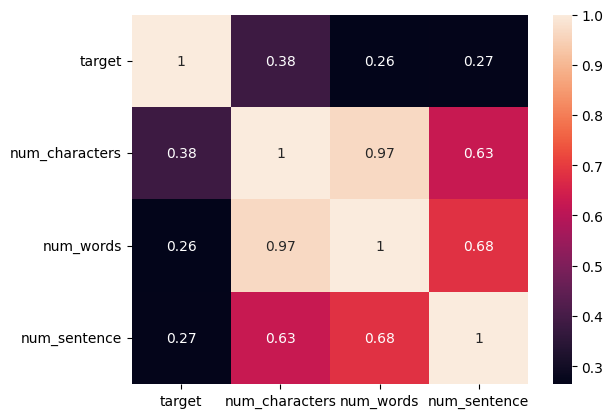

In [34]:
# Selecting only numeric columns from the DataFrame 'df' to create a new DataFrame 'numeric_df'
# This excludes non-numeric columns such as object/string types
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Calculating the correlation matrix for the numeric columns
correlation_matrix = numeric_df.corr()

# Visualizing the correlation matrix using a heatmap with annotations
# This provides a graphical representation of the correlations between numeric features
sns.heatmap(correlation_matrix, annot=True)


In [35]:
df.columns

Index(['target', 'text', 'num_characters', 'num_words', 'num_sentence'], dtype='object')

**Text data preprocessing**

In [36]:
#remove stopwords
from nltk.corpus import stopwords


In [37]:
stopwords.words('english')

['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 "you're",
 "you've",
 "you'll",
 "you'd",
 'your',
 'yours',
 'yourself',
 'yourselves',
 'he',
 'him',
 'his',
 'himself',
 'she',
 "she's",
 'her',
 'hers',
 'herself',
 'it',
 "it's",
 'its',
 'itself',
 'they',
 'them',
 'their',
 'theirs',
 'themselves',
 'what',
 'which',
 'who',
 'whom',
 'this',
 'that',
 "that'll",
 'these',
 'those',
 'am',
 'is',
 'are',
 'was',
 'were',
 'be',
 'been',
 'being',
 'have',
 'has',
 'had',
 'having',
 'do',
 'does',
 'did',
 'doing',
 'a',
 'an',
 'the',
 'and',
 'but',
 'if',
 'or',
 'because',
 'as',
 'until',
 'while',
 'of',
 'at',
 'by',
 'for',
 'with',
 'about',
 'against',
 'between',
 'into',
 'through',
 'during',
 'before',
 'after',
 'above',
 'below',
 'to',
 'from',
 'up',
 'down',
 'in',
 'out',
 'on',
 'off',
 'over',
 'under',
 'again',
 'further',
 'then',
 'once',
 'here',
 'there',
 'when',
 'where',
 'why',
 'how',
 'all',
 'any',
 'both',
 'each

In [38]:
#remove punctuations
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [39]:
# Importing the PorterStemmer class from the nltk.stem.porter module for stemming
from nltk.stem.porter import PorterStemmer

# Creating an instance of the PorterStemmer class
ps = PorterStemmer()

# Stemming the word 'having' using the Porter stemming algorithm
ps.stem('having')


'have'

In [40]:
def transform_text(text):
    """
    Preprocesses the input text by converting to lowercase, tokenizing, removing special characters,
    stopwords, punctuation, and stemming each word.

    Args:
        text (str): The input text to be transformed.

    Returns:
        str: The preprocessed text.
    """
    # Convert text to lowercase
    text = text.lower()

    # Tokenize the text
    text = nltk.word_tokenize(text)

    # Initialize an empty list to store processed tokens
    y = []

    # Remove special characters
    for i in text:
        if i.isalnum():
            y.append(i)
    
    # Update text with cleaned tokens
    text = y[:]
    y.clear()

    # Remove stopwords and punctuation
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    
    # Update text with cleaned tokens
    text = y[:]
    y.clear()

    # Stem the text
    for i in text:
        y.append(ps.stem(i))

    # Join the stemmed tokens to form the preprocessed text
    return " ".join(y)


In [42]:
# Applying the 'transform_text' function to preprocess the 'text' column of DataFrame 'df'
# The preprocessed text is stored in a new column 'transformed_text'
df['transformed_text'] = df['text'].apply(transform_text)


In [43]:
# Tokenize the text in the 'transformed_text' column
tokenized_text = df['transformed_text'].apply(nltk.word_tokenize)

# Flatten the list of tokenized words
all_words = [word for sublist in tokenized_text for word in sublist]
# Count the unique words
unique_word_count = len(set(all_words))

print("Unique words count in transformed_text:", unique_word_count)


Unique words count in transformed_text: 6657


In [44]:
df.head(2)

,target,text,num_characters,num_words,num_sentence,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,23,2,go jurong point avail bugi n great world la e ...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni


Checking the most used word in form spam and ham message

In [45]:
# Importing the WordCloud class from the wordcloud module
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')


In [46]:
# Generating a word cloud specifically for spam messages by concatenating preprocessed text from the 'transformed_text' column
# This filters the DataFrame to include only rows where 'target' is 1 (indicating spam messages), then concatenates the preprocessed text
# The WordCloud object 'wc' is used to generate the word cloud for the concatenated text
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))


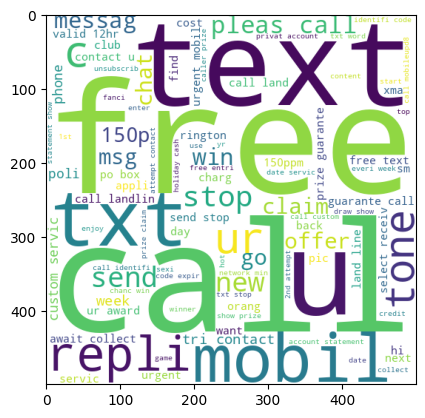

In [47]:
# Displaying the generated word cloud for spam messages using matplotlib
plt.imshow(spam_wc)


In [48]:
# Generating a word cloud specifically for ham (non-spam) messages by concatenating preprocessed text from the 'transformed_text' column
# This filters the DataFrame to include only rows where 'target' is 0 (indicating ham messages), then concatenates the preprocessed text
# The WordCloud object 'wc' is used to generate the word cloud for the concatenated text
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))


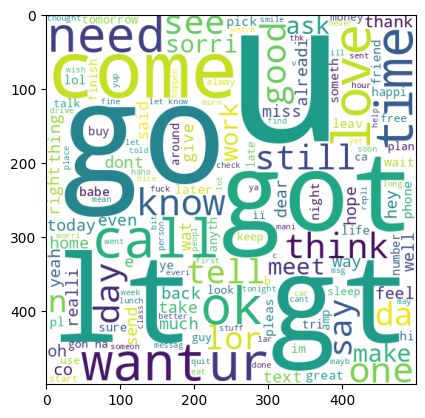

In [49]:
# Displaying the generated word cloud for ham (non-spam) messages using matplotlib
plt.imshow(ham_wc)



finding the most common words

In [50]:
# Extracting words from each spam message in the 'transformed_text' column and storing them in the list 'most_common_words'
# This loops through each spam message in the DataFrame where 'target' is 1, splits the message into words,
# and appends each word to the list 'most_common_words'
most_common_words = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        most_common_words.append(word)


In [51]:
len(most_common_words)

9883

In [52]:
# Importing the Counter class from the collections module
from collections import Counter

# Calculating the length of the 30 most common words extracted from the spam messages
# Counter(most_common_words) creates a Counter object to count the occurrences of each word
# most_common(30) method returns the 30 most common words along with their counts as a list of tuples
len(Counter(most_common_words).most_common(30))


30

**Model Building**

Tokenization  using bag of tokenizer


In [53]:
# Importing the Tokenizer class from the tensorflow.keras.preprocessing.text module
from tensorflow.keras.preprocessing.text import Tokenizer

# Initializing the Tokenizer
tokenizer = Tokenizer()

# Fitting the Tokenizer on the preprocessed text data in the 'transformed_text' column of the DataFrame
tokenizer.fit_on_texts(df['transformed_text'])

# Converting the preprocessed text data into sequences of integers using the Tokenizer
text_to_sequence = tokenizer.texts_to_sequences(df['transformed_text'])


2024-05-10 09:47:56.399941: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-10 09:47:56.400074: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-10 09:47:56.524184: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [54]:
# Printing the preprocessed text and its corresponding numerical sequence for the first 5 samples
for i in range(5):
    print("Text               : ", df['transformed_text'][i])
    print("Numerical Sequence : ", text_to_sequence[i])


Text               :  go jurong point avail bugi n great world la e buffet cine got amor wat
Numerical Sequence :  [4, 3111, 266, 566, 947, 40, 64, 300, 948, 94, 2132, 949, 13, 3112, 65]
Text               :  ok lar joke wif u oni
Numerical Sequence :  [19, 229, 567, 314, 1, 1414]
Text               :  free entri 2 wkli comp win fa cup final tkt 21st may text fa 87121 receiv entri question std txt rate c appli 08452810075over18
Numerical Sequence :  [12, 406, 3, 782, 783, 130, 2133, 1076, 301, 2134, 2135, 188, 21, 2133, 2136, 218, 406, 328, 1077, 28, 307, 67, 308, 3113]
Text               :  u dun say earli hor u c alreadi say
Numerical Sequence :  [1, 150, 41, 275, 2137, 1, 67, 76, 41]
Text               :  nah think goe usf live around though
Numerical Sequence :  [739, 26, 329, 740, 182, 129, 330]


In [55]:
#tokenizer.index_word

In [56]:
import tensorflow as tf

In [57]:
from tensorflow.keras.layers import Dense, Embedding, LSTM, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [58]:
# Finding the length of the largest sequence in the list of numerical sequences
max_length_sequence = max([len(i) for i in text_to_sequence])

# Padding the numerical sequences to make them all the same length using the pad_sequences function
# The 'maxlen' parameter specifies the maximum length to pad sequences to (which is the length of the largest sequence)
# The 'padding' parameter specifies the padding position, 'pre' means padding is added at the beginning of sequences
padded_sms_sequence = pad_sequences(text_to_sequence, maxlen=max_length_sequence, padding="pre")

# Displaying the padded numerical sequences
padded_sms_sequence


array([[   0,    0,    0, ...,   13, 3112,   65],
       [   0,    0,    0, ...,  314,    1, 1414],
       [   0,    0,    0, ...,   67,  308, 3113],
       ...,
       [   0,    0,    0, ..., 6657, 1394, 1245],
       [   0,    0,    0, ...,  743,  141,   12],
       [   0,    0,    0, ..., 1906,  453,  184]], dtype=int32)

In [59]:
# Extracting the target values (labels) from the 'target' column of the DataFrame and storing them in 'y'
y = df['target'].values


In [60]:
# Importing the train_test_split function from the sklearn.model_selection module
from sklearn.model_selection import train_test_split

# Splitting the padded numerical sequences (X) and target values (y) into training and testing sets
# The test_size parameter specifies the proportion of the dataset to include in the test split
# The random_state parameter ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(padded_sms_sequence, y, test_size=0.2, random_state=2)

# Printing the shapes of the training data (X_train) and corresponding target values (y_train)
X_train.shape, y_train.shape


((4135, 74), (4135,))

In [61]:
# Calculating the total size of the vocabulary, including one additional token for unknown words
# The total size is determined by the number of unique tokens in the tokenizer's word index plus one
# The additional one is for unknown words, which are not present in the tokenizer's word index
TOT_SIZE = len(tokenizer.word_index) + 1
TOT_SIZE


6658

In [62]:
# Defining a function to create a new LSTM model
def create_model(): 
    # Initializing a sequential model
    lstm_model = Sequential()

    # Adding an embedding layer with vocabulary size TOT_SIZE, embedding dimension 32, and input length max_length_sequence
    lstm_model.add(Embedding(TOT_SIZE, 32, input_length=max_length_sequence))

    # Adding an LSTM layer with 100 units
    lstm_model.add(LSTM(100))

    # Adding a dropout layer to prevent overfitting
    lstm_model.add(Dropout(0.4))

    # Adding a dense layer with 20 units and ReLU activation function
    lstm_model.add(Dense(20, activation="relu"))

    # Adding another dropout layer
    lstm_model.add(Dropout(0.3))

    # Adding a dense layer with 1 unit and sigmoid activation function for binary classification
    lstm_model.add(Dense(1, activation="sigmoid"))

    return lstm_model

# Creating a new LSTM model
new_lstm_model = create_model()

# Compiling the model with binary crossentropy loss function, adam optimizer, and accuracy metric
new_lstm_model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])


/opt/conda/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:86: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [63]:
# Displaying a summary of the architecture of the new LSTM model
new_lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [64]:
# Training the new LSTM model on the training data (X_train, y_train)
# The model is trained for 5 epochs with a validation split of 20%
# The batch size is set to 16
history_new = new_lstm_model.fit(X_train, y_train, epochs=5, validation_split=0.2, batch_size=16)


Epoch 1/5
207/207 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8847 - loss: 0.3255 - val_accuracy: 0.9722 - val_loss: 0.0986
Epoch 2/5
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9840 - loss: 0.0564 - val_accuracy: 0.9758 - val_loss: 0.0838
Epoch 3/5
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9979 - loss: 0.0135 - val_accuracy: 0.9770 - val_loss: 0.0933
Epoch 4/5
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9977 - loss: 0.0071 - val_accuracy: 0.9794 - val_loss: 0.1336
Epoch 5/5
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9995 - loss: 0.0015 - val_accuracy: 0.9770 - val_loss: 0.1543


In [142]:
y_pred2[:20]

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

In [66]:
new_lstm_model.save("text_model_new_rnn.h5")

In [67]:
# Importing the matplotlib.pyplot module for data visualization
import matplotlib.pyplot as plt

def plot_loss_curves(history):
    """Plot separate loss curves for training and validation."""
    # Extracting training and validation loss values from the history object
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    
    # Extracting training and validation accuracy values from the history object
    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]
    
    # Determining the number of epochs
    epochs = range(len(history.history["loss"]))
    
    # Plotting loss curves
    plt.plot(epochs, loss, label="training_loss")
    plt.plot(epochs, val_loss, label="val_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()
    plt.show()  # Display the plot
    
    # Plotting accuracy curves
    plt.figure()
    plt.plot(epochs, accuracy, label="training_accuracy")
    plt.plot(epochs, val_accuracy, label="val_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()
    plt.show()  # Display the plot


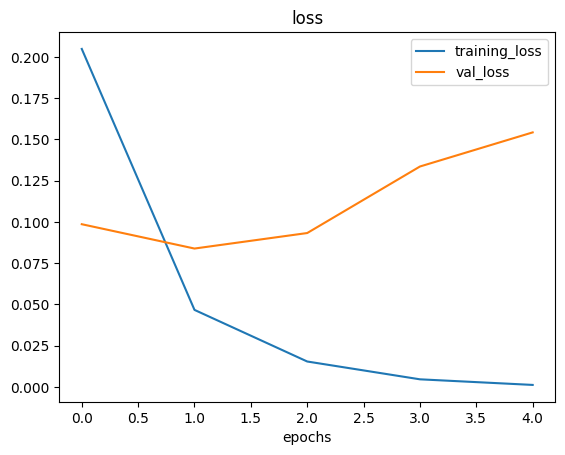

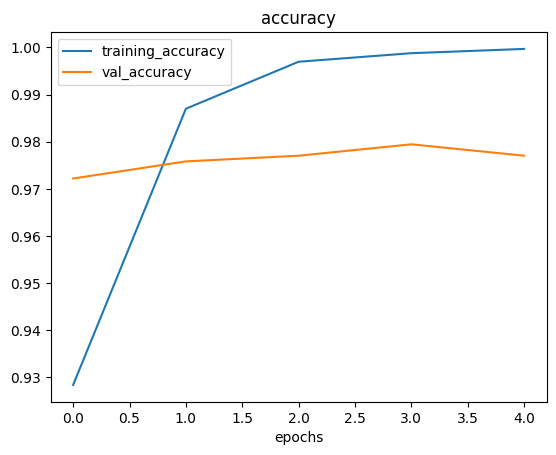

In [68]:
plot_loss_curves(history_new)

In [77]:
# Importing necessary modules for model evaluation
from sklearn.model_selection import cross_val_score
from matplotlib.colors import ListedColormap
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report, accuracy_score, f1_score
from sklearn import metrics


In [70]:
# Making predictions on the test data using the trained LSTM model
y_pred = new_lstm_model.predict(X_test)


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [72]:
import numpy as np

# Set the threshold for binary classification
threshold = 0.50

# Initialize an array to store binary predictions
binary_predictions = np.zeros_like(y_pred, dtype=int)

# Iterate through each prediction probability and assign binary predictions based on the threshold
for i, prob in enumerate(y_pred):
    if prob > threshold:
        binary_predictions[i] = 1  # Predict "Spam"
    elif prob < (1 - threshold):
        binary_predictions[i] = 0  # Predict "Ham"
    else:
        # Additional logic based on text data
        text_data = X_test[i]  # Assuming X_test contains text data
        # Apply some logic based on text_data to make a prediction

# Now binary_predictions contains binary predictions (0 for "Ham" and 1 for "Spam")


In [73]:
binary_predictions

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [74]:
y_pred_binary.shape,y_test.shape

((1034, 1), (1034,))

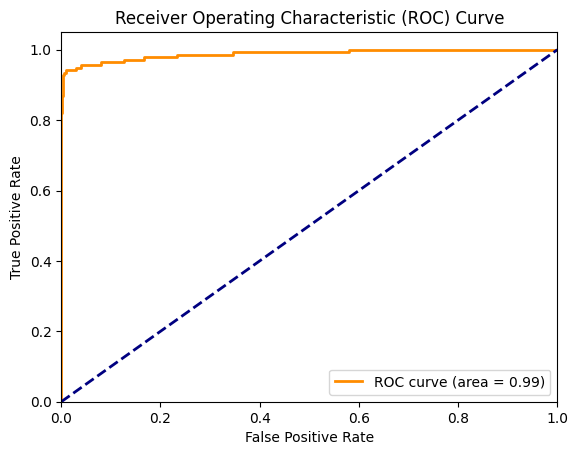

Precision: 0.9624060150375939
Recall: 0.927536231884058
Confusion Matrix:
[[891   5]
 [ 10 128]]
Accuracy: 0.9854932301740812


In [84]:
# Importing necessary modules for calculating and visualizing evaluation metrics
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Calculate precision, recall, and confusion matrix
precision = precision_score(y_test, binary_predictions)
recall = recall_score(y_test, binary_predictions)
conf_matrix = confusion_matrix(y_test, binary_predictions)

# Calculate accuracy
accuracy = accuracy_score(y_test, binary_predictions)

# Print evaluation metrics
print("Precision:", precision)
print("Recall:", recall)
print("Confusion Matrix:")
print(conf_matrix)
print("Accuracy:", accuracy)


**Evaluation**

In [96]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenizing and padding the new text data
sequences = tokenizer.texts_to_sequences([sms_text])
padded_sequences = pad_sequences(sequences, maxlen=max_sequence_length)  

# Predicting the probability of the text being spam or ham
predicted_probability = new_lstm_model.predict(padded_sequences)[0][0]  

# Applying a threshold to determine the final prediction
threshold = 0.5  # You can adjust this threshold as needed
if predicted_probability > threshold:
    prediction = "Spam"
else:
    prediction = "Ham"

# Printing the predicted probability and final prediction
print("Predicted Probability:", predicted_probability)
print("Prediction:", prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Predicted Probability: 0.88855237
Prediction: Spam
